## Importation des paquets requis

In [1]:
import sys
sys.path.append('/opt/ros/noetic/lib/python3/dist-packages/')
sys.path.append('/usr/lib/python3/dist-packages')
import numpy as np
from lab_utils.plan_utils import *
from matplotlib import pyplot as plt
from matplotlib import image as mpimg
import cv2
import rospy
from std_msgs.msg import Float32MultiArray
from jackal_msgs.msg import Drive
from geometry_msgs.msg import Pose, PoseStamped, PoseWithCovarianceStamped
from time import sleep

## Importation de la carte (format png)

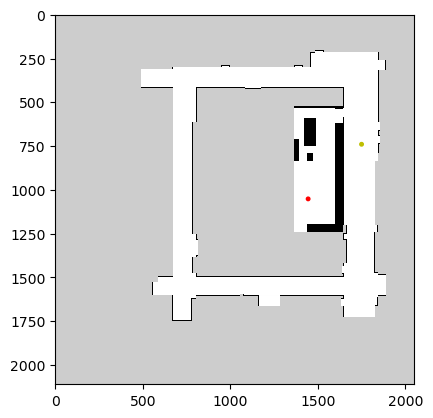

In [2]:
fig, ax = plt.subplots()
image = mpimg.imread("Maps/a2230_map_closed.png")
start = Point(1444.7, 1052.1)
end = Point(1750, 740)

plt.imshow(image)
ax.add_artist(plt.Circle((start.x, start.y), 10, color='r'))
ax.add_artist(plt.Circle((end.x, end.y), 10, color='y'))
plt.show()

In [3]:
map_img = 1-np.array(image[:,:,1])
print(map_img.shape)
mat_map = map_img
map = BMPMap(width=map_img.shape[1], height=map_img.shape[0], mat=mat_map)

(2112, 2048)


## Trajectoire avec A*

In [4]:
from lab_utils.astart import AStarPlanner
astarPlanner = AStarPlanner(map=map, step_size=10, collision_radius=12, heuristic_dist='Euclidean')
astarPlanner.plan(start=start, target=end)

Done !


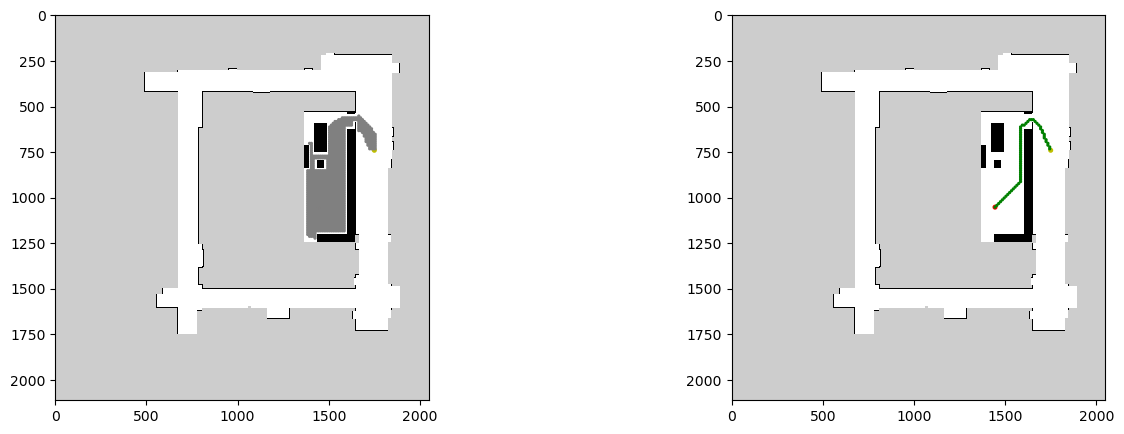

In [5]:
fig = plt.figure(figsize=(16,5))
ax = fig.add_subplot(1, 2, 1)
plt.imshow(image)
ax.add_artist(plt.Circle((start.x, start.y), 10, color='r'))
ax.add_artist(plt.Circle((end.x, end.y), 10, color='y'))
for i in range(len(astarPlanner.open_list)-1):
    pt = astarPlanner.open_list[i].pos.tuple()
    ax.add_artist(plt.Circle((pt[0], pt[1]), 5, color='gray'))
for i in range(len(astarPlanner.close_list)-1):
    pt = astarPlanner.close_list[i].pos.tuple()
    ax.add_artist(plt.Circle((pt[0], pt[1]), 5, color='gray'))

ax2 = fig.add_subplot(1, 2, 2)
plt.imshow(image)
ax2.add_artist(plt.Circle((start.x, start.y), 10, color='r'))
ax2.add_artist(plt.Circle((end.x, end.y), 10, color='y'))
for i in range(len(astarPlanner.finalPath)-1):
    pt = astarPlanner.finalPath[i].tuple()
    ax2.add_artist(plt.Circle((pt[0], pt[1]), 5, color='g'))
plt.show()

## Trajectoire avec RRT

In [6]:
from lab_utils.rrt import RRTPlanner
rrtPlanner = RRTPlanner(map, epsilon=0.05, stepSize=5)
rrtPlanner.plan(start=start, target=end)

final


In [7]:
rospy.init_node('dingo_controller', anonymous=True)
rate = rospy.Rate(50)

cmd_drive_pub = rospy.Publisher('/mobile_manip/dingo_velocity_controller/cmd_drive', Drive, queue_size=1)

interwheel_distance = 0.46
left_wheel_radius = 0.045
right_wheel_radius = 0.045
def move_robot(linear, angular):
    vel_left  = (linear - angular * interwheel_distance / 2.0) / left_wheel_radius
    vel_right = (linear + angular * interwheel_distance / 2.0) / right_wheel_radius

    # Envoi des commandes au roues par topic ROS
    cmd_drive_msg = Drive()
    cmd_drive_msg.drivers[0] = vel_left
    cmd_drive_msg.drivers[1] = vel_right
    cmd_drive_pub.publish(cmd_drive_msg)

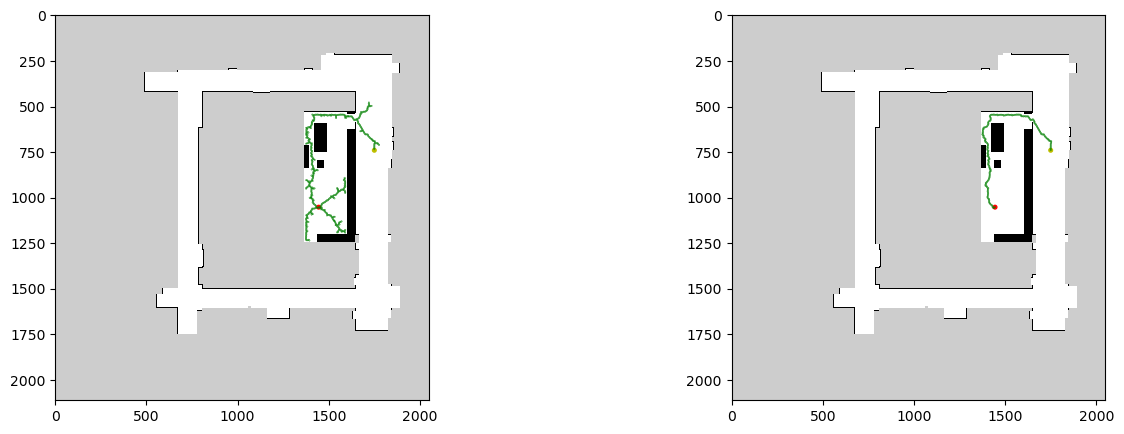

[(0.0, -0.0), (-3.9521368837001773, -3.0627788122058064), (-8.889712562134946, -3.8503995456362645), (-12.958828273410518, -0.9448363767737646), (-13.342858600059117, 4.040393879514795), (-15.790135481387779, 8.400535604976767), (-19.159707971806483, 12.094582333405242), (-23.403190247172006, 14.738983622668911), (-27.277873175744162, 17.8991785854887), (-28.99062063747283, 22.5966775085692), (-32.87857568586924, 25.74052953143041), (-32.179353253548925, 30.691396929184066), (-31.65928699595588, 35.66427648611216), (-33.362523909582706, 40.365232135345536), (-32.84661059251471, 45.33854425598224), (-37.5071947927579, 47.1493327340886), (-40.32459392047576, 51.2799818544006), (-41.74485828392085, 56.07402494326914), (-39.56759505322998, 60.57508313265987), (-39.62770543799138, 65.57472179376771), (-39.198373896061184, 70.55625513472853), (-37.68042500624233, 75.32026932109466), (-38.21706679790282, 80.29138746367016), (-40.29576209511197, 84.83880715634871), (-40.126157472667956, 89.835

In [32]:
traj = []
fig = plt.figure(figsize=(16,5))
ax = fig.add_subplot(1, 2, 1)
plt.imshow(image)
ax.add_artist(plt.Circle((start.x, start.y), 10, color='r'))
ax.add_artist(plt.Circle((end.x, end.y), 10, color='y'))
for i in range(len(rrtPlanner.nodeList)-1):
    pt = rrtPlanner.nodeList[i].pos.tuple()
    ax.add_artist(plt.Circle((pt[0], pt[1]), 1, color='g'))
ax2 = fig.add_subplot(1, 2, 2)
plt.imshow(image)
ax2.add_artist(plt.Circle((start.x, start.y), 10, color='r'))
ax2.add_artist(plt.Circle((end.x, end.y), 10, color='y'))
for i in range(len(rrtPlanner.finalPath)-1):
    pt = rrtPlanner.finalPath[i].tuple()
    ax2.add_artist(plt.Circle((pt[0], pt[1]), 1, color='g'))
    traj.append(rrtPlanner.finalPath[i].tuple())
plt.show()

for i in traj:
    temp = list(i)  
    temp[0] -= 1444.7 
    temp[1] -= 1052.1 
    temp[1] *= -1
    traj[traj.index(i)] = tuple(temp) 

print(traj)

In [9]:
# AMCL_pose callback (pour la visualisation de la pose)
pose_msg = Pose()
def amcl_callback(msg):
    global pose_msg
    pose_msg = msg.pose.pose
    pose = PoseStamped()

    pose.header.seq = 1
    pose.header.stamp = rospy.Time.now()
    pose.header.frame_id = "map"

    pose.pose.position.x = pose_msg.position.x
    pose.pose.position.y = pose_msg.position.y
    pose.pose.position.z = 0.0

    pose.pose.orientation.x = pose_msg.orientation.x
    pose.pose.orientation.y = pose_msg.orientation.y
    pose.pose.orientation.z = pose_msg.orientation.z
    pose.pose.orientation.w = pose_msg.orientation.w

    #pose_pub.publish(pose)

amcl_sub = rospy.Subscriber('/amcl_pose', PoseWithCovarianceStamped, amcl_callback)

print(pose_msg.orientation.z) #en demi-tour

0.0


In [33]:
def goto (pos):

    x = pos[0] - pose_msg.position.x
    y = pos[1] - pose_msg.position.y
    angle = np.arctan(y/x) - pose_msg.orientation.z*np.pi
    line = np.sqrt(x*x+y*y)
    print("obj :", line, angle)
    print(x,y)
    while (np.abs(x)>0.001 and np.abs(y)>0.001):
        move_robot(0, angle)
        sleep(1)
        print(angle, pose_msg.orientation.z)
        move_robot(line/10,0)
        sleep(1)
        print(x, pose_msg.position.x, y, pose_msg.position.y)
        x = pos[0] - pose_msg.position.x
        y = pos[1] - pose_msg.position.y
        line = np.sqrt(x*x+y*y)
        angle = np.arctan(y/x) - pose_msg.orientation.z
    

In [34]:
for i in traj:
    goto(i)


obj : 1.1253281964158932 0.6297293613080737
-1.095270665313987 -0.25835192925794714
0.6297293613080737 0.09778040763685816
-1.095270665313987 1.0070208585144615 -0.25835192925794714 -0.1720731376928924
-0.47130489709400203 0.20032690082264856
-1.0070208585144615 0.9203800456472243 0.1720731376928924 0.0708614936265792
0.020363252326564163 0.05647671679054919
-0.9203800456472243 1.0286957050196832 -0.0708614936265792 0.04175317950483222
-0.006431217812042547 0.04699741591005397
-1.0286957050196832 1.1362778899763564 -0.04175317950483222 0.02654580958848813
-0.01731516360931073 0.04067299003082754
-1.1362778899763564 1.2435844434713483 -0.02654580958848813 0.055576404465078985
0.004821413529627977 0.039839364610113
-1.2435844434713483 1.3475103097923342 -0.055576404465078985 0.08780995509429458
0.02853513564711778 0.03653744852811776
-1.3475103097923342 1.4550122154871186 -0.08780995509429458 0.12640996458439063
0.050233079431577066 0.0364282903327558
-1.4550122154871186 1.56602136960173

KeyboardInterrupt: 